# Pretraining Analysis

Inspect the self-supervised pretraining: the checkpoint, what the per-bin spectral projection learned, and how synthetic GC-MS chromatograms are constructed from MoNA/MassBank spectra.

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')
sys.path.insert(0, str(Path('..').resolve()))
import chroma_dcnn; sys.modules.setdefault('msformer', chroma_dcnn)
import chroma_dcnn.models, chroma_dcnn.training

CKPT_PATH = Path('../checkpoints/chroma_pretrain/best.pt')
DATA_DIR  = Path('../data/pretraining')

ckpt = torch.load(CKPT_PATH, map_location='cpu', weights_only=False)
cfg  = ckpt['config']

print('=== Checkpoint summary ===')
print(f'  Config:        {cfg}')
print(f'  Final loss:    {ckpt["final_loss"]:.6f}')
print(f'  Iterations:    {ckpt["n_iterations"]:,}')
print(f'  spec_proj:     Linear({cfg.mz_max} → {cfg.cnn_channels})')
print(f'  CNN:           3× ResBlock1d (kernel={cfg.kernel_size})')

=== Checkpoint summary ===
  Config:        ChromaPretrainConfig(mz_max=1000, n_bins=200, cnn_channels=128, kernel_size=7, dropout=0.1)
  Final loss:    0.000337
  Iterations:    20,000
  spec_proj:     Linear(1000 → 128)
  CNN:           3× ResBlock1d (kernel=7)


## 1 — Spectral projection weight analysis

The 128×1000 weight matrix of the per-bin spectral projection. Each row is a learned spectral filter.

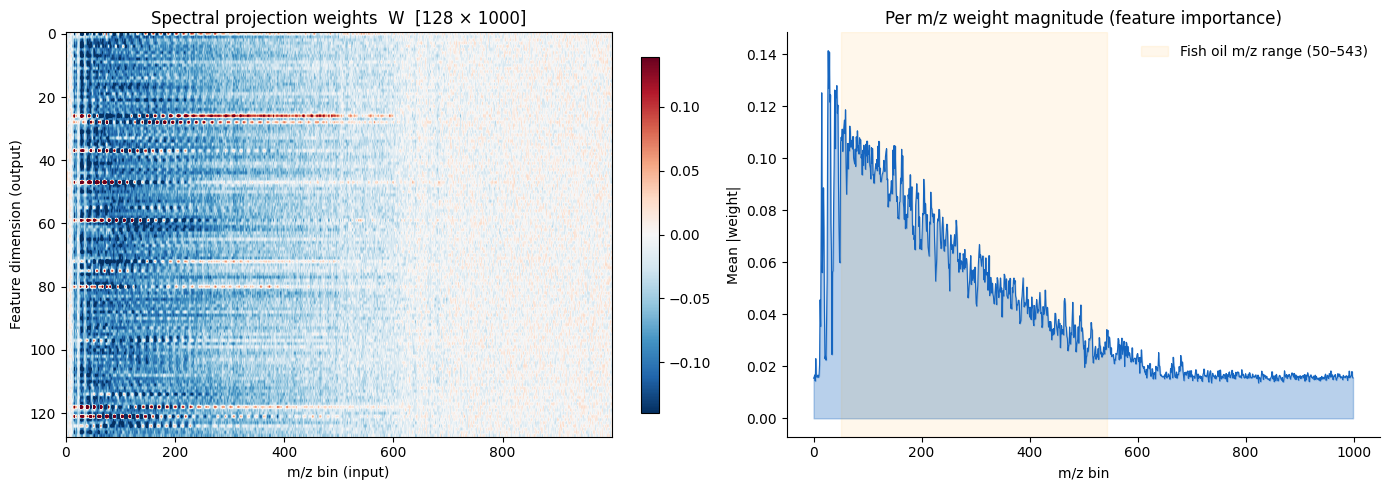

In [2]:
W = ckpt['spec_proj_state']['weight'].numpy()   # [128, 1000]
b = ckpt['spec_proj_state']['bias'].numpy()     # [128]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Weight matrix heatmap
im = axes[0].imshow(W, aspect='auto', cmap='RdBu_r',
                    vmin=-W.std()*3, vmax=W.std()*3)
plt.colorbar(im, ax=axes[0], fraction=0.03)
axes[0].set_xlabel('m/z bin (input)')
axes[0].set_ylabel('Feature dimension (output)')
axes[0].set_title('Spectral projection weights  W  [128 × 1000]')

# Weight magnitude per m/z bin
mag = np.abs(W).mean(axis=0)   # [1000]
axes[1].plot(mag, linewidth=0.8, color='#1565c0')
axes[1].fill_between(np.arange(1000), mag, alpha=0.3, color='#1565c0')
axes[1].axvspan(50, 543, alpha=0.08, color='orange', label='Fish oil m/z range (50–543)')
axes[1].set_xlabel('m/z bin')
axes[1].set_ylabel('Mean |weight|')
axes[1].set_title('Per m/z weight magnitude (feature importance)')
axes[1].legend(frameon=False)
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()

## 2 — PCA of the spectral filters

Project the 128 learned filters into 2D to see if they cluster into interpretable groups.

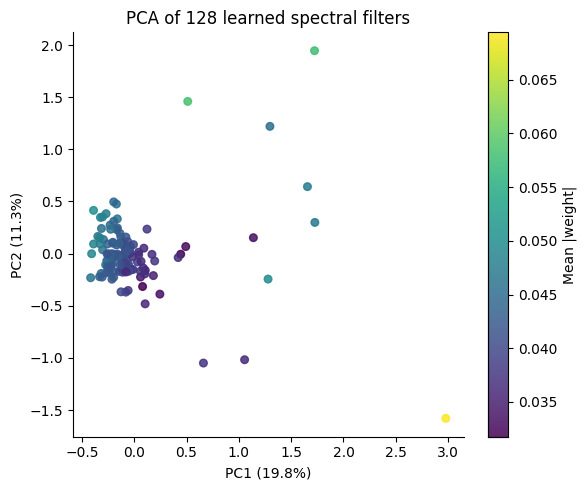

In [3]:
pca      = PCA(n_components=2, random_state=0)
W_pca    = pca.fit_transform(W)   # [128, 2]

# Colour by mean weight magnitude
mag_vec  = np.abs(W).mean(axis=1)

fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(W_pca[:, 0], W_pca[:, 1],
                c=mag_vec, cmap='viridis', s=30, alpha=0.85)
plt.colorbar(sc, ax=ax, label='Mean |weight|')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('PCA of 128 learned spectral filters')
sns.despine()
plt.tight_layout()
plt.show()

## 3 — Synthetic chromatogram examples

The pretraining data: EI-MS spectra from MoNA/MassBank placed at random RT positions to form synthetic 2D chromatograms.

Loaded 200 pretraining spectra from ../data/pretraining/spectra.h5


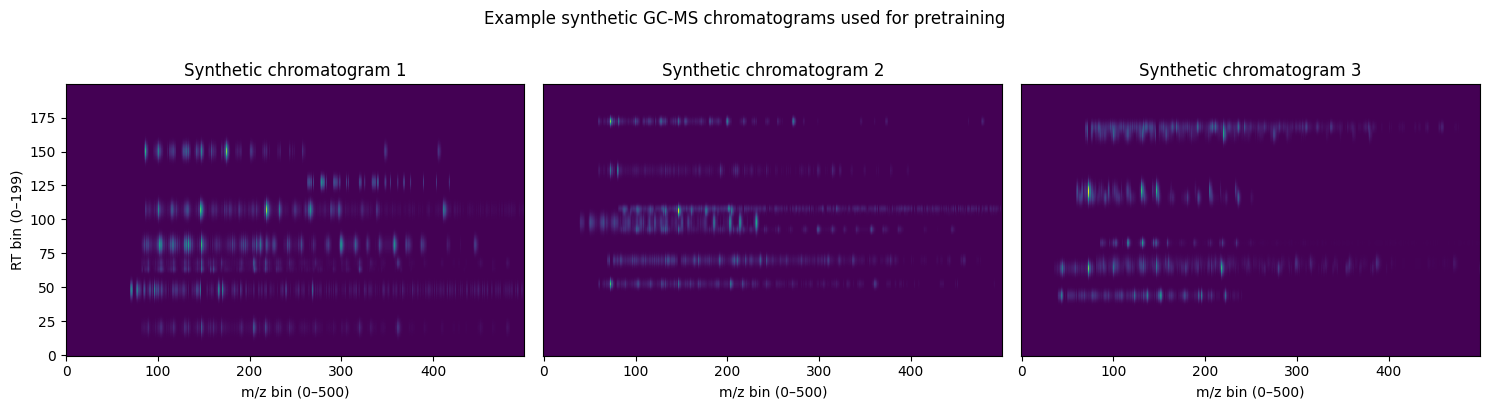

In [4]:
import h5py

h5_path = DATA_DIR / 'spectra.h5'
if not h5_path.exists():
    print('spectra.h5 not found — run scripts/02_preprocess_pretrain_data.py to build it.')
else:
    with h5py.File(h5_path, 'r') as f:
        spectra = f['spectra'][:200]   # [200, 1000]
        print(f'Loaded {spectra.shape[0]} pretraining spectra from {h5_path}')

    def make_synthetic_chromatogram(spectra, n_bins=200, n_compounds=8, seed=0):
        """Place n_compounds random spectra at Gaussian RT positions."""
        rng   = np.random.default_rng(seed)
        chroma = np.zeros((n_bins, 1000), dtype=np.float32)
        for _ in range(n_compounds):
            spec   = spectra[rng.integers(len(spectra))].copy()
            rt_c   = rng.uniform(0.1, 0.9) * n_bins
            rt_sig = rng.uniform(1.5, 4.0)
            amp    = rng.uniform(0.3, 1.0)
            for i in range(n_bins):
                w = amp * np.exp(-0.5 * ((i - rt_c) / rt_sig) ** 2)
                chroma[i] += w * spec
        return np.clip(chroma, 0, None)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for i, ax in enumerate(axes):
        c = make_synthetic_chromatogram(spectra, seed=i)
        ax.imshow(np.log1p(c[:, :500]), aspect='auto', origin='lower', cmap='viridis')
        ax.set_title(f'Synthetic chromatogram {i+1}')
        ax.set_xlabel('m/z bin (0–500)')
        if i == 0:
            ax.set_ylabel('RT bin (0–199)')
        else:
            ax.set_yticks([])

    plt.suptitle('Example synthetic GC-MS chromatograms used for pretraining', y=1.01)
    plt.tight_layout()
    plt.show()

## 4 — Compare per-bin projections: pretrained vs random

  Loaded pretrained spec_proj from ../checkpoints/chroma_pretrain/best.pt
  Loaded pretrained CNN from ../checkpoints/chroma_pretrain/best.pt


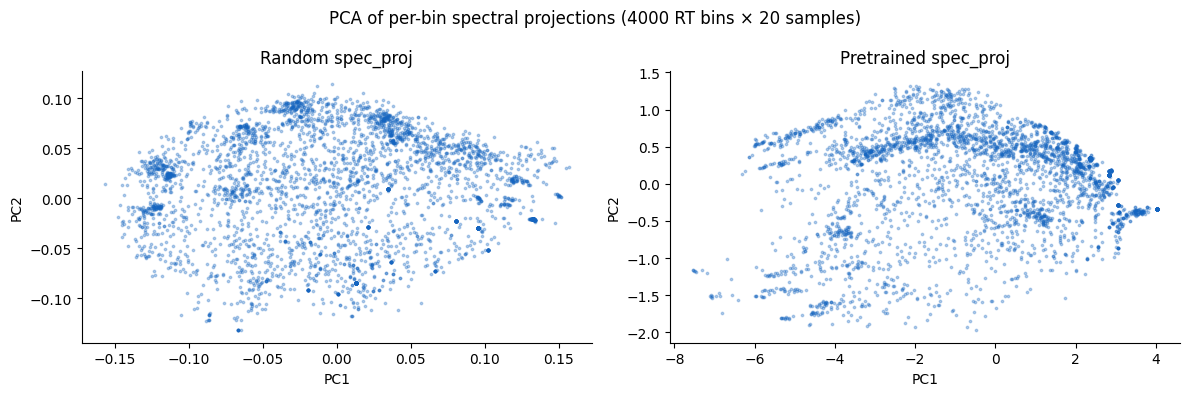

In [5]:
DATA_DIR_FISH = Path('../data/fish_oil')
npz_paths = sorted((DATA_DIR_FISH / 'chroma').glob('*.npz'))[:20]   # 20 samples
chromas   = np.stack([np.load(p)['chroma'] for p in npz_paths])     # [20, 200, 1000]
X_t       = torch.tensor(chromas, dtype=torch.float32)

from chroma_dcnn.models.chroma_cnn import ChromatogramCNN, ChromaCNNConfig

cfg_model = ChromaCNNConfig(mz_max=1000, cnn_channels=128, kernel_size=7,
                             num_classes=4, dropout=0.3)

torch.manual_seed(0)
model_rand = ChromatogramCNN(cfg_model)
model_pre  = ChromatogramCNN(cfg_model)
model_pre.load_pretrained_chroma_encoder(str(CKPT_PATH))

with torch.no_grad():
    B, N, mz = X_t.shape
    emb_rand = model_rand.spec_proj(X_t.reshape(B*N, mz)).numpy()   # [4000, 128]
    emb_pre  = model_pre.spec_proj(X_t.reshape(B*N, mz)).numpy()

pca2 = PCA(n_components=2, random_state=0)
r2d  = pca2.fit_transform(emb_rand)
p2d  = pca2.fit_transform(emb_pre)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, emb2d, title in zip(axes, [r2d, p2d],
                             ['Random spec_proj', 'Pretrained spec_proj']):
    ax.scatter(emb2d[:, 0], emb2d[:, 1], s=3, alpha=0.3, color='#1565c0')
    ax.set_title(title)
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    sns.despine(ax=ax)

plt.suptitle('PCA of per-bin spectral projections (4000 RT bins × 20 samples)')
plt.tight_layout()
plt.show()